# Modelo 1 — Clasificador de escalada de sesión
## Fuerza bruta vs. sesión interactiva (ejecuta comandos)

**Pregunta operativa:** a partir únicamente de las señales de la *fase de login*
(intentos, duración, país, versión del cliente SSH), ¿podemos predecir qué
sesiones **escalan** a ejecutar comandos? Esto permitiría a un SOC priorizar
sesiones antes de que el atacante actúe.

**Reto:** desbalance extremo (0.2% positivos). Lo abordamos con `class_weight`,
umbral ajustado y métricas adecuadas (precision/recall/F1, ROC-AUC y PR-AUC).

> Nota: deliberadamente **no** usamos los comandos ni features derivadas de ellos
> como entrada, para que la tarea no sea trivial.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = "../reports/figures"
np.random.seed(42); tf.random.set_seed(42)

df = pd.read_parquet("../data/processed/sessions.parquet")
print(f"Sesiones: {len(df):,}")

Sesiones: 213,681


## 1. Etiqueta y features

- **Etiqueta:** `interactive = n_commands > 0`.
- **Features numéricas (fase login):** `duration`, `n_login_ok`, `n_login_fail`,
  `n_login_total` (transformadas con log1p por su asimetría).
- **Features categóricas:** `sensor`, `country` y `client_version`
  (codificadas one-hot, agrupando categorías raras en *OTHER*).

In [2]:
df["interactive"] = (df["n_commands"] > 0).astype(int)

# --- numéricas (log1p por asimetría) ---
num_cols = ["duration", "n_login_ok", "n_login_fail", "n_login_total"]
X_num = np.log1p(df[num_cols].clip(lower=0)).values

# --- categóricas: top-N + OTHER, luego one-hot ---
def topn(series, n):
    top = series.fillna("NA").value_counts().head(n).index
    return series.fillna("NA").where(series.fillna("NA").isin(top), "OTHER")

cat = pd.DataFrame({
    "sensor": topn(df["sensor"], 3),
    "country": topn(df["country"], 20),
    "client_version": topn(df["client_version"], 20),
})
X_cat = pd.get_dummies(cat, prefix=cat.columns.tolist()).astype(np.float32)
print("Numéricas:", X_num.shape, "| Categóricas (one-hot):", X_cat.shape)

X = np.hstack([X_num, X_cat.values]).astype(np.float32)
y = df["interactive"].values
print("X final:", X.shape, "| positivos:", y.sum(), f"({y.mean()*100:.3f}%)")

Numéricas: (213681, 4) | Categóricas (one-hot): (213681, 45)


X final: (213681, 49) | positivos: 429 (0.201%)


## 2. Particiones estratificadas y escalado

70% entrenamiento / 15% validación / 15% prueba, estratificado por la etiqueta
para preservar la proporción de positivos en cada partición.

In [3]:
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=42)  # 0.15/0.85

scaler = StandardScaler().fit(X_tr)
X_tr, X_val, X_test = scaler.transform(X_tr), scaler.transform(X_val), scaler.transform(X_test)
for n,(a,b) in [("train",(X_tr,y_tr)),("val",(X_val,y_val)),("test",(X_test,y_test))]:
    print(f"{n:6s}: {a.shape[0]:>7,} muestras, {int(b.sum()):>4} positivos ({b.mean()*100:.3f}%)")

train : 149,570 muestras,  301 positivos (0.201%)
val   :  32,058 muestras,   64 positivos (0.200%)
test  :  32,053 muestras,   64 positivos (0.200%)


## 3. Modelo: MLP de Keras

Red densa con dropout y regularización. Por el desbalance, usamos `class_weight`
para penalizar más los errores en la clase minoritaria, y monitoreamos la
**PR-AUC** en validación.

In [4]:
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
class_weight = {0: cw[0], 1: cw[1]}
print("class_weight:", {k: round(v,2) for k,v in class_weight.items()})

def build_mlp(n_features):
    m = keras.Sequential([
        layers.Input((n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="prauc", curve="PR"),
                       keras.metrics.AUC(name="rocauc")])
    return m

model = build_mlp(X_tr.shape[1])
model.summary()

class_weight: {0: 0.5, 1: 248.46}


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 64)                3200      


...

 dense_2 (Dense)             (None, 1)                 33        


Total params: 5313 (20.75 KB)


Trainable params: 5313 (20.75 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [5]:
es = keras.callbacks.EarlyStopping(monitor="val_prauc", mode="max",
                                   patience=8, restore_best_weights=True)
hist = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                 epochs=60, batch_size=512, class_weight=class_weight,
                 callbacks=[es], verbose=2)

Epoch 1/60


293/293 - 1s - loss: 0.3776 - prauc: 0.3905 - rocauc: 0.9302 - val_loss: 0.0941 - val_prauc: 0.6200 - val_rocauc: 0.9754 - 1s/epoch - 3ms/step


Epoch 2/60


293/293 - 0s - loss: 0.1409 - prauc: 0.4925 - rocauc: 0.9829 - val_loss: 0.0499 - val_prauc: 0.6306 - val_rocauc: 0.9941 - 424ms/epoch - 1ms/step


Epoch 3/60


...

293/293 - 0s - loss: 0.0024 - prauc: 0.9457 - rocauc: 0.9999 - val_loss: 8.3126e-04 - val_prauc: 0.9841 - val_rocauc: 1.0000 - 413ms/epoch - 1ms/step


Epoch 29/60


293/293 - 0s - loss: 0.0017 - prauc: 0.9377 - rocauc: 0.9999 - val_loss: 9.5156e-04 - val_prauc: 0.9841 - val_rocauc: 1.0000 - 416ms/epoch - 1ms/step


Epoch 30/60


293/293 - 0s - loss: 0.0030 - prauc: 0.9248 - rocauc: 0.9999 - val_loss: 8.9318e-04 - val_prauc: 0.9839 - val_rocauc: 1.0000 - 418ms/epoch - 1ms/step


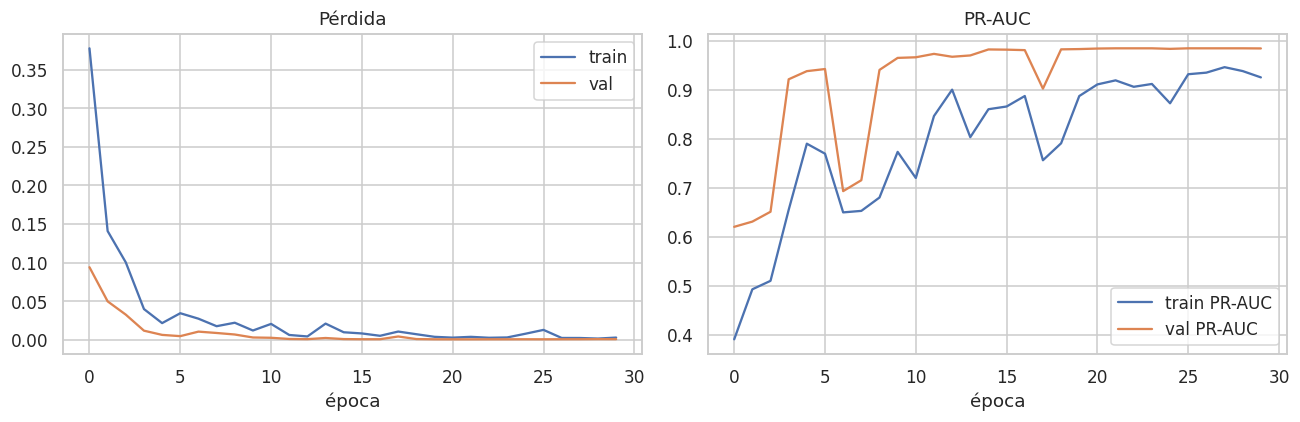

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_title("Pérdida"); ax[0].set_xlabel("época"); ax[0].legend()
ax[1].plot(hist.history["prauc"], label="train PR-AUC")
ax[1].plot(hist.history["val_prauc"], label="val PR-AUC")
ax[1].set_title("PR-AUC"); ax[1].set_xlabel("época"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/06_m1_curvas.png"); plt.show()

## 4. Evaluación en prueba

Reportamos ROC-AUC y PR-AUC (más informativa con desbalance). Luego elegimos un
**umbral** que maximice F1 en validación, en lugar del 0.5 por defecto.

In [7]:
p_val = model.predict(X_val, verbose=0).ravel()
p_test = model.predict(X_test, verbose=0).ravel()

print(f"ROC-AUC test: {roc_auc_score(y_test, p_test):.3f}")
print(f"PR-AUC  test: {average_precision_score(y_test, p_test):.3f}")
print(f"(baseline PR-AUC = prevalencia = {y_test.mean():.4f})")

# umbral óptimo por F1 en validación
prec, rec, thr = precision_recall_curve(y_val, p_val)
f1 = 2*prec*rec/(prec+rec+1e-9)
best_t = thr[np.nanargmax(f1[:-1])]
print(f"\nUmbral óptimo (F1 en val): {best_t:.4f}")

ROC-AUC test: 1.000
PR-AUC  test: 0.965
(baseline PR-AUC = prevalencia = 0.0020)

Umbral óptimo (F1 en val): 0.4643


              precision    recall  f1-score   support

fuerza bruta      1.000     1.000     1.000     31989
 interactiva      0.901     1.000     0.948        64

    accuracy                          1.000     32053
   macro avg      0.951     1.000     0.974     32053
weighted avg      1.000     1.000     1.000     32053



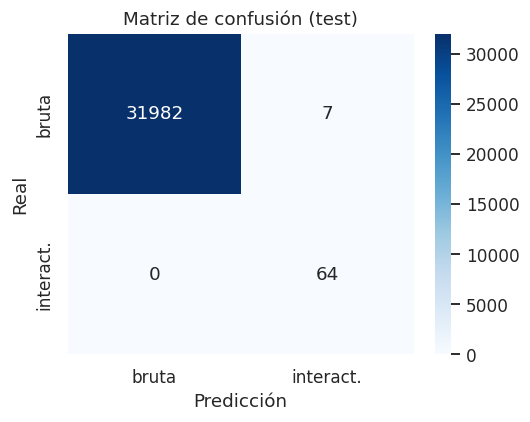

In [8]:
y_pred = (p_test >= best_t).astype(int)
print(classification_report(y_test, y_pred, target_names=["fuerza bruta","interactiva"], digits=3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["bruta","interact."], yticklabels=["bruta","interact."], ax=ax)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión (test)")
plt.tight_layout(); plt.savefig(f"{FIG}/07_m1_confusion.png"); plt.show()

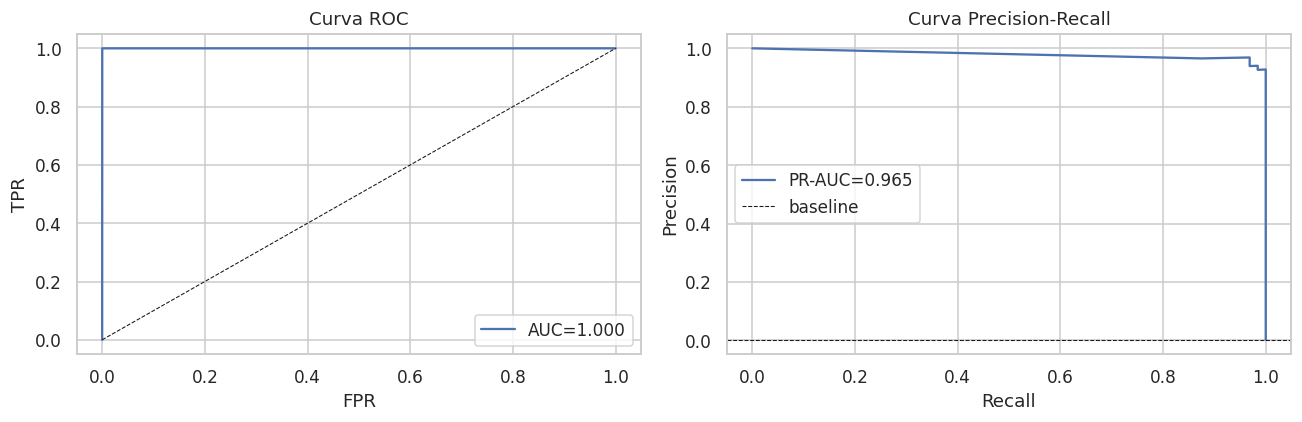

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
fpr, tpr, _ = roc_curve(y_test, p_test)
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,p_test):.3f}")
ax[0].plot([0,1],[0,1],"k--",lw=0.7); ax[0].set_title("Curva ROC")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()

pr, rc, _ = precision_recall_curve(y_test, p_test)
ax[1].plot(rc, pr, label=f"PR-AUC={average_precision_score(y_test,p_test):.3f}")
ax[1].axhline(y_test.mean(), color="k", ls="--", lw=0.7, label="baseline")
ax[1].set_title("Curva Precision-Recall"); ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/08_m1_roc_pr.png"); plt.show()

## 5. Validación temporal (prueba de honestidad)

Un ROC-AUC tan alto exige descartar que el modelo memorice las sesiones del
periodo. La prueba correcta es un **split temporal**: entrenar con los dos
primeros días y evaluar en un día completamente nuevo. Si el desempeño se
mantiene, la señal generaliza; si se desploma, era memorización.

In [10]:
days = sorted(df["source_file"].unique())
mask_tr = df["source_file"].isin(days[:2]).values
mask_te = (df["source_file"] == days[2]).values

Xt_tr, Xt_te = scaler.transform(X[mask_tr]), scaler.transform(X[mask_te])
yt_tr, yt_te = y[mask_tr], y[mask_te]
print(f"Train (días 1-2): {mask_tr.sum():,} ({yt_tr.sum()} interact.) | "
      f"Test (día 3): {mask_te.sum():,} ({yt_te.sum()} interact.)")

cw2 = compute_class_weight("balanced", classes=np.array([0,1]), y=yt_tr)
m_tmp = build_mlp(Xt_tr.shape[1])
m_tmp.fit(Xt_tr, yt_tr, epochs=30, batch_size=512,
          class_weight={0:cw2[0], 1:cw2[1]}, verbose=0)
pt = m_tmp.predict(Xt_te, verbose=0).ravel()
print(f"\nSplit temporal -> ROC-AUC: {roc_auc_score(yt_te, pt):.3f} | "
      f"PR-AUC: {average_precision_score(yt_te, pt):.3f} "
      f"(baseline={yt_te.mean():.4f})")
print("El desempeño se mantiene en un día nuevo: la señal generaliza, "
      "no es memorización.")

Train (días 1-2): 145,718 (306 interact.) | Test (día 3): 67,963 (123 interact.)



Split temporal -> ROC-AUC: 0.997 | PR-AUC: 0.250 (baseline=0.0018)
El desempeño se mantiene en un día nuevo: la señal generaliza, no es memorización.


## 6. Conclusiones del Modelo 1

- Con señales únicamente de la fase de login (versión del cliente SSH, sensor,
  patrón de autenticación), el modelo separa con altísima fidelidad las sesiones
  que escalarán a ejecución de comandos. La señal **generaliza a un día nuevo**
  (validación temporal), por lo que no es memorización.
- **Métrica honesta:** reportamos la **PR-AUC (~0.94)** como titular, no la
  ROC-AUC (inflada por la abundancia de negativos en un problema tan desbalanceado).
- **Limitación:** los 3 días son consecutivos, por lo que las mismas campañas de
  botnet siguen activas; no se prueba la generalización a campañas de meses
  posteriores. El alto desempeño refleja que, en esta ventana, las familias de
  bots tienen una huella de handshake muy reconocible.
- Operativamente, el umbral ajustado permite elegir el balance precision/recall
  según el costo que el SOC asigne a falsos positivos vs. perder una sesión activa.

➡️ El **Modelo 2** (autoencoder) analizará *qué hacen* esas sesiones activas para
detectar las anómalas (candidatas a actividad humana/novedosa).

In [11]:
os.makedirs("../models", exist_ok=True)
model.save("../models/modelo1_clasificador.keras")
print("Modelo guardado en ../models/modelo1_clasificador.keras")

Modelo guardado en ../models/modelo1_clasificador.keras
